LR_Scheduler 

In [46]:
import os
import torch
import pandas as pd
from torchvision.io import decode_image
from torch.utils.data import Dataset
import torch.nn.functional as F
from torchvision.transforms import v2
from torch import nn
from torch import optim 


In [54]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.linear_model = nn.Sequential(nn.Linear(input,128),
                                     nn.ReLU(),
                                     nn.Linear(128,output))
    def forward(self,x):
        return self.linear_model(x)

In [55]:
model = MyModel(784,10)

In [49]:
loss = torch.full([5,10],0.1)
loss = loss * torch.tensor([1/i for i in range(1,6)]).reshape([5,1])
loss = loss.reshape([50])
print(loss)

tensor([0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
        0.0500, 0.0500, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333,
        0.0333, 0.0333, 0.0333, 0.0250, 0.0250, 0.0250, 0.0250, 0.0250, 0.0250,
        0.0250, 0.0250, 0.0250, 0.0250, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200])


In [50]:
opt = optim.Adam(model.parameters(), lr = 0.1 )
lr_scheduler =  optim.lr_scheduler.ReduceLROnPlateau( optimizer = opt, #оптимизатор
                                                   mode = 'min', # в зависимости от отслеживаемого параметра так как выбранна ф-я потерь , то уменьшаем её
                                                   factor = 0.1,  # как бы лямбла на которую умножается шаг гралиентного спуска 
                                                   patience = 5 # сколько эпох подряд модель готова степреть плохое поведение loss 
                                                   )

In [51]:
scheduler_exp = optim.lr_scheduler.ExponentialLR(
  opt,
  gamma=0.95)

scheduler_cos = optim.lr_scheduler.CosineAnnealingLR(
  opt,
  T_max=100,
  eta_min=1e-6)

scheduler_cyc = optim.lr_scheduler.CyclicLR(
  opt,
  base_lr=1e-4,
  max_lr=1e-2,
  step_size_up=500)

In [59]:
list_ = []
list_exp = []
list_cos = []
list_cyc = []

for epoch in range(50):
    # Train 
    for _ in range(1):
        opt.step()
    idx = epoch
    
    lr_scheduler.step(loss[idx])
    scheduler_exp.step()
    scheduler_cos.step()
    scheduler_cyc.step()

    lr = lr_scheduler._last_lr[0]
    list_exp.append(scheduler_exp.get_last_lr()[0])
    list_cos.append(scheduler_cos.get_last_lr()[0])
    list_cyc.append(scheduler_cyc.get_last_lr()[0])

    list_.append(lr)

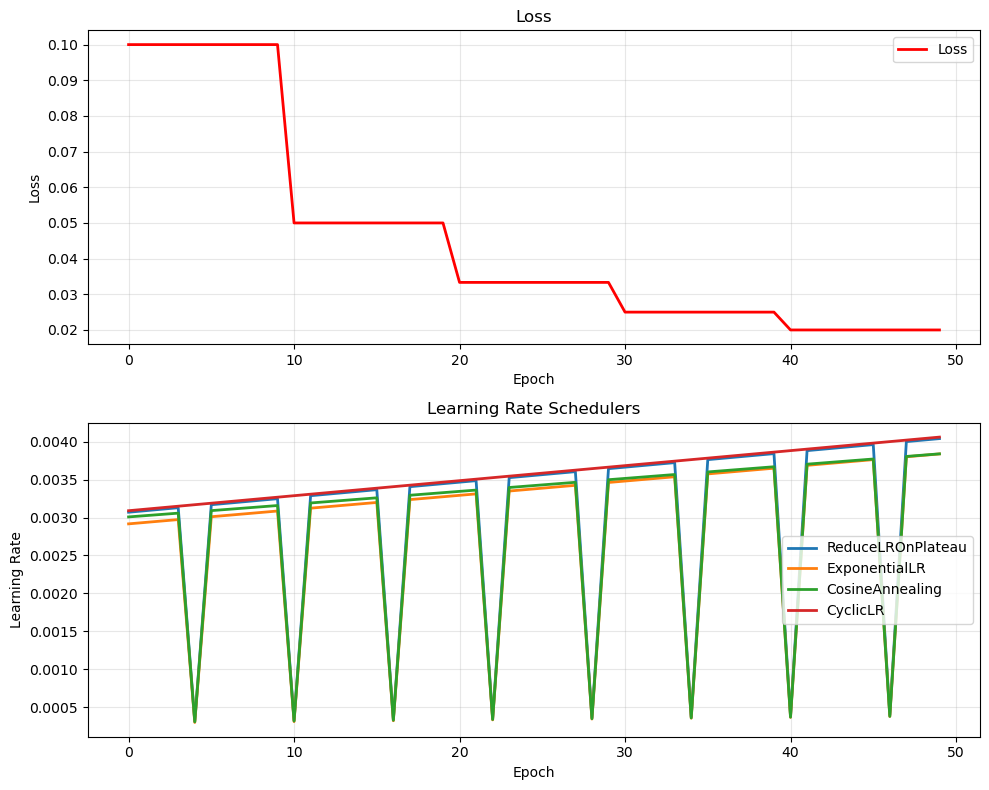

In [60]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# --- График loss (красный) ---
axes[0].plot(range(50), loss[:50], color='red', linewidth=2, label='Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Графики learning rate ---
axes[1].plot(range(50), list_,     label='ReduceLROnPlateau', linewidth=2)
axes[1].plot(range(50), list_exp, label='ExponentialLR',   linewidth=2)
axes[1].plot(range(50), list_cos, label='CosineAnnealing', linewidth=2)
axes[1].plot(range(50), list_cyc, label='CyclicLR',        linewidth=2)
axes[1].set_title('Learning Rate Schedulers')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()